# SCOUBI Tutorial

This notebook walks through a full SCOUBI analysis for spatial transcriptomics data with transcript coordinates and cell-level annotations. We will load data, bin the tissue, train the axon-versus-dendrite model, identify interface regions, and profile the expression and communication signals concentrated around those interfaces.

SCOUBI is designed for studies where unresolved neurite structure matters. By the end of the workflow, you will have an annotated `AnnData` object containing spatial maps, enrichment results, interface-level summaries, and communication profiles that can be reused for downstream analysis or saved to disk.

## Workflow at a glance

1. Load transcript-level data and optional cell annotations
2. Bin the tissue into a regular spatial grid
3. Train the bin annotator with marker genes and ligand-receptor pairs
4. Build axon, dendrite, and interface maps
5. Quantify enrichment, interface expression, and communication structure
6. Save the processed object for later reuse

## Package layout

| Submodule | Alias | Purpose |
|---|---|---|
| `scoubi.io` | - | Data loading and AnnData helpers |
| `scoubi.preprocess` | `scoubi.pp` | Spatial binning |
| `scoubi.model` | `scoubi.md` | Axon/dendrite annotation model |
| `scoubi.tools` | `scoubi.tl` | Downstream analysis utilities |
| `scoubi.plotting` | `scoubi.pl` | Visualization helpers |


## 0. Imports

We start with the core scientific Python stack and the SCOUBI modules used throughout the notebook.


In [1]:
import scoubi
import numpy as np
import pandas as pd
import anndata as ad
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import colorcet as cc
from adjustText import adjust_text
from scipy.spatial import cKDTree
import time
import psutil
import os

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/storage/home/hcoda1/6/baggarwal9/.conda/envs/SCOUBI/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/storage/home/hcoda1/6/baggarwal9/.conda/envs/SCOUBI/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/storage/home/hcoda1/6/baggarwal9/.conda/envs/SCOUBI/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


Using device: cuda


In [2]:
# ── Notebook-wide timing & resource tracking ──────────────────────────────────
_nb_start    = time.perf_counter()
_nb_proc     = psutil.Process(os.getpid())
_nb_ram_base = _nb_proc.memory_info().rss / 1024**3   # GB at kernel start

# System info
print(f"CPUs (logical)  : {psutil.cpu_count()}")
print(f"Total RAM       : {psutil.virtual_memory().total / 1024**3:.1f} GB")
print(f"Available RAM   : {psutil.virtual_memory().available / 1024**3:.1f} GB")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}           : {props.name}  ({props.total_memory / 1024**3:.1f} GB VRAM)")
else:
    print("GPU             : not available")
print(f"Baseline RAM use: {_nb_ram_base:.2f} GB")

CPUs (logical)  : 64
Total RAM       : 2014.9 GB
Available RAM   : 1528.4 GB
GPU 0           : NVIDIA H200  (139.8 GB VRAM)
Baseline RAM use: 0.78 GB


## 1. Load the data

Use `scoubi.io.load_data` to read either a raw transcript table (`.parquet` or `.csv`) or a previously saved `.h5ad` object. In the raw-table path, SCOUBI builds a cell-by-gene matrix, stores spatial coordinates, and attaches convenience helpers for transcript access and summary printing.

For CSV or Parquet input, the transcript table should contain:
- `cell_id` for transcript-to-cell assignment
- `gene` or `feature_name` for gene symbols
- `x_location` and `y_location` for spatial coordinates
- optional `z_location` and `qv`

| Parameter | Type | Default | Description |
|---|---|---|---|
| `filename` | `str` | - | Path to `.parquet`, `.csv`, or `.h5ad` |
| `cell_type` | `str` | `None` | CSV with cell-type labels indexed by cell ID |
| `region` | `str` | `None` | CSV with region labels indexed by cell ID |
| `qv_thresold` | `float` | `None` | Minimum quality-value score for transcript filtering |
| `filter_genes` | `tuple[str]` | built in | Gene-name prefixes to exclude, such as blanks and controls |
| `usr_label` | `str` | `'UNASSIGNED'` | Cell ID used for unassigned transcripts |
| `overwrite` | `bool` | `False` | If `True`, reuse the input path for the sidecar Parquet |

After loading, the returned `AnnData` object contains a sparse count matrix in `X`, mean spatial coordinates in `obsm['spatial']`, the transcript sidecar path in `uns['transcripts_path']`, plus the helper methods `adata.summarize()` and `adata.get_transcripts()`.


In [3]:
adata = scoubi.io.load_data(
    filename   = "/storage/home/hcoda1/6/baggarwal9/r-ssinha338-0/TBN/extracellular/data/transcripts_d2_tutorial.parquet",   # or .csv; or a saved .h5ad
    cell_type  = "/storage/home/hcoda1/6/baggarwal9/r-ssinha338-0/TBN/extracellular/data/cell_type.csv", # CSV: index=cell_id, one column of labels
    region     = "/storage/home/hcoda1/6/baggarwal9/r-ssinha338-0/TBN/extracellular/data/regions.csv",    # CSV: index=cell_id, one column of region labels
    qv_thresold= 20,                    # drop transcripts with quality-value < 20
    filter_genes=('BLANK', 'NegControl', 'DeprecatedCodeword',
                  'UnassignedCodeword', 'Blank'),  # prefixes to remove
    usr_label  = 'UNASSIGNED',          # how unassigned transcripts are labelled
    overwrite  = True,                  # write sidecar parquet to same path as input
)

print(adata)

AnnData object with n_obs × n_vars = 63162 × 5027
    obs: 'cell_type', 'region'
    uns: 'transcripts_path'
    obsm: 'spatial'


## 2. Bin the tissue

Next we convert the cell-by-gene object into a spatial grid with `scoubi.pp.bin_data`. This step turns transcript coordinates into regular spatial bins so later model and interface calculations operate on a consistent tissue map.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `adata` | `AnnData` | - | Object returned by `load_data` |
| `binsize` | `int` or `float` | - | Spatial width of each bin in the same coordinate units as the data |

The main results are stored on the `AnnData` object: `uns['binned_data']` contains the flattened bin-by-gene matrix, `uns['binned_data_shape']` records the grid shape, `uns['mask_ecm']` and `uns['mask_cell']` describe the tissue masks, and `obsm['bin']` stores bin coordinates for each cell.


In [4]:
adata = scoubi.pp.bin_data(
    adata,
    binsize = 2,   # 2-unit bins; smaller = finer resolution, larger = faster
)

print('Binned data shape:', adata.uns['binned_data_shape'])   # [X_BINS, Y_BINS, n_genes]
print('ECM mask shape:   ', adata.uns['mask_ecm'].shape)
print('Cell mask shape:  ', adata.uns['mask_cell'].shape)
print('Number of genes:  ', len(adata.uns['genes']))

Binned data shape: [3626, 2538, 5027]
ECM mask shape:    (3626, 2538)
Cell mask shape:   (3626, 2538)
Number of genes:   5027


In [5]:
# # Lazy-load the full transcript table (cached after first call)
# transcripts = adata.get_transcripts()
# transcripts.load()  # returns a pandas DataFrame
# transcripts.load().head()

## 3. Train the bin annotator

`scoubi.md.train` fits a lightweight neural network that assigns extrasomatic bins to axon or dendrite identity. The model combines marker-gene separation with a ligand-receptor communication objective, which helps encourage spatially coherent predictions near putative interfaces.

A practical way to think about the training inputs is:
- marker genes provide the compartment labels you trust biologically,
- ligand-receptor pairs provide neighborhood-level structure,
- the learned probabilities become the foundation for all downstream maps.

### Choosing a variance model

The communication score uses a null-variance estimate controlled by `iid`.

| `iid` | Behavior | When to use it |
|---|---|---|
| `True` | Fast closed-form variance estimate | Good default for most runs |
| `False` | Full spatial covariance estimate | More conservative but slower and heavier |

### Marker genes

Use genes with strong compartment-specific localization. For murine neural tissue, example markers include axonal genes such as `Bsn`, `Gap43`, `Slc17a7`, `Syn1`, and `Vamp2`, and dendritic genes such as `Camk2a`, `Dlg4`, `Gria1`, `Homer1`, `Map2`, and `Shank3`.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `adata` | `AnnData` | - | Output from `bin_data` |
| `axon_markers` | `list[str]` | - | Axon marker genes |
| `dendrite_markers` | `list[str]` | - | Dendrite marker genes |
| `pairs` | `list[tuple]` or `None` | `None` | Ligand-receptor pairs; uses the bundled reference when omitted |
| `epochs` | `int` | `500` | Maximum training epochs |
| `lambda_gex` | `float` | `0.1` | Weight on the marker-separation loss |
| `lambda_comm` | `float` | `1.0` | Weight on the communication loss |
| `ftemp` | `float` | `0.1` | Temperature used for final probabilities |
| `patience` | `int` | `50` | Early-stopping patience |
| `lr` | `float` | `1e-3` | AdamW learning rate |
| `weight_decay` | `float` | `1e-4` | AdamW weight decay |
| `device` | `str` | `'cpu'` | `'cpu'` or `'cuda'` |
| `seed` | `int` | `42` | Random seed |
| `tol` | `float` | `1e-2` | Minimum improvement for resetting patience |
| `do_comm` | `bool` | `True` | Whether to include the communication term |
| `iid` | `bool` | `True` | Null-variance model for the communication score |

Training adds the learned weights, marker lists, ligand-receptor pairs, bin probabilities, and raw bin scores to `adata.uns`.


In [6]:
axon_markers = [
    'Bsn', 'Gap43', 'Slc17a6', 'Slc17a7', 'Slc32a1',
    'Snap25', 'Stx1a', 'Syn1', 'Syp', 'Vamp2', 'Kif5a', 'Kif5c', 'Snph'
]

dendrite_markers = [
    'Camk2a', 'Dlg3', 'Dlg4', 'Gphn', 'Gria1', 'Gria2',
    'Homer1', 'Nlgn2', 'Nlgn3', 'Shank3', 'Map2', 'Bdnf', 'Mapk8ip1'
]

# --- resource snapshot before training ---
_proc = psutil.Process(os.getpid())
_ram_before = _proc.memory_info().rss / 1024**3          # GB
_cpu_before = psutil.cpu_percent(interval=None)
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats(device)
_train_start = time.perf_counter()

adata = scoubi.md.train(
    adata,
    axon_markers,
    dendrite_markers,
    device       = device,
    epochs       = 1000,
    ftemp        = 0.1,    # temperature: lower → sharper class boundary
)

# --- resource snapshot after training ---
_train_elapsed = time.perf_counter() - _train_start
_ram_after = _proc.memory_info().rss / 1024**3
_cpu_after = psutil.cpu_percent(interval=None)

print(f"\n{'='*45}")
print(f"  Model training time : {_train_elapsed/60:.1f} min  ({_train_elapsed:.1f} s)")
print(f"  RAM before / after  : {_ram_before:.2f} GB → {_ram_after:.2f} GB  (Δ {_ram_after - _ram_before:+.2f} GB)")
print(f"  CPU usage (post)    : {_cpu_after:.1f}%")
if torch.cuda.is_available():
    _gpu_peak = torch.cuda.max_memory_allocated(device) / 1024**3
    _gpu_cur  = torch.cuda.memory_allocated(device) / 1024**3
    print(f"  GPU peak / current  : {_gpu_peak:.2f} GB / {_gpu_cur:.2f} GB")
print(f"{'='*45}\n")

print('bin_probabilities shape:', adata.uns['bin_probabilities'].shape)  # (n_bins, 2)
print('L-R pairs used in training:', len(adata.uns['lr_pairs']))

Epoch 681/1000 | Total: -32.406048 | GEX: -27.341766 | Comm: -5.064280 | Patience: 49/50:  68%|██████▊   | 680/1000 [06:30<03:03,  1.74epoch/s]



Early stopping at epoch 680. Loss did not improve for 50 epochs.

  Model training time : 11.3 min  (678.0 s)
  RAM before / after  : 49.89 GB → 50.79 GB  (Δ +0.90 GB)
  CPU usage (post)    : 47.9%
  GPU peak / current  : 49.06 GB / 0.06 GB

bin_probabilities shape: (9202788, 2)
L-R pairs used in training: 361


## 4. Build the spatial overview

With trained bin probabilities in hand, `scoubi.tl.overview` turns soft predictions into the main spatial summaries used throughout the rest of the workflow. This step creates axon, dendrite, and interface maps and runs CellWhisper, a z-score-based screen for ligand-receptor pairs enriched across the axon-dendrite boundary.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `adata` | `AnnData` | - | Output from `train` |
| `threshold` | `float` | `0.5` | Probability cutoff for binarizing axon and dendrite maps |
| `zscore_threshold` | `float` | `3.0` | Minimum CellWhisper z-score |
| `cw_edges_threshold` | `float` | `30` | Minimum edge count for retained CellWhisper pairs |
| `device` | `torch.device` | `cpu` | Device used for convolution-heavy steps |

The key outputs are `axon_map`, `dendrite_map`, `interface_map`, the filtered and unfiltered CellWhisper tables, and the ligand-receptor pairs that pass the significance filters.


In [7]:
adata = scoubi.tl.overview(
    adata,
    device     = device,
)

print('Interface bins:', adata.uns['interface_map'].sum())
print('Significant L-R pairs:', len(adata.uns['cellwhisper_lr']))
adata.uns['cellwhisper'].head()

╭─────────────────────────────────────────────────── Overview ────────────────────────────────────────────────────╮
│                                                                                                                 │
│   Total bins               9,202,788                                                                            │
│   USR bins                 4,237,831 (46.0%)                                                                    │
│   Cell bins                1,874,655 (20.4%)                                                                    │
│   Overlap bins             0 (0.0%)                                                                             │
│   Axonic bins              1,128,425 (12.3%)                                                                    │
│   Dendritic bins           1,037,973 (11.3%)                                                                    │
│   Number of Interfaces     31,189 (0.3%)                                                                        │
│   Interface bins           66,461 (0.7%)                                                                        │
│   Significant L-R pairs    67 / 361                                                                             │
│   Pairs with null < 0.05   67 (max=9.15e-05)                                                                    │
│   Axonic Probabilities     0.5–0.6: ████████████████████ (928404)                                               │
│                            0.6–0.7: ███ (172677)                                                                │
│                            0.7–0.8:  (24474)                                                                    │
│                            0.8–0.9:  (2755)                                                                     │
│                            0.9–1.0:  (115)                                                                      │
│   Dendritic Probabilities  0.5–0.6: ████████████████████ (871538)                                               │
│                            0.6–0.7: ██ (129394)                                                                 │
│                            0.7–0.8:  (32846)                                                                    │
│                            0.8–0.9:  (3998)                                                                     │
│                            0.9–1.0:  (197)                                                                      │
│   Interface Probabilities  0.5–0.6: ████████████████████ (40317)                                                │
│                            0.6–0.7: █████████ (18401)                                                           │
│                            0.7–0.8: ███ (6413)                                                                  │
│                            0.8–0.9:  (1250)                                                                     │
│                            0.9–1.0:  (80)                                                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Interface bins: 66461.0
Significant L-R pairs: 67


,L,R,zscore,N,X,p_a,p_d,p_l_global,p_r_global,p_null_joint
1,Gad1,Gabrg2,25.107569,2158018.0,390.0,0.011278,0.004834,0.003622,0.001724,7.940187e-07
8,Slc32a1,Gabbr1,31.593853,2158018.0,2248.0,0.012431,0.043543,0.004541,0.016807,3.775033e-05
16,Slc17a6,Gria1,11.555967,2158018.0,1533.0,0.010111,0.052355,0.001313,0.006016,1.372721e-06
20,Gad1,Gabbr1,23.999872,2158018.0,1841.0,0.011278,0.043543,0.003622,0.016807,2.888499e-05
39,Slc17a7,Grin1,84.327843,2158018.0,13320.0,0.178354,0.016921,0.022951,0.005856,8.863613e-05


In [8]:
if torch.cuda.is_available():
    print(f"\n  GPU")
    for i in range(torch.cuda.device_count()):
        props   = torch.cuda.get_device_properties(i)
        cur_gb  = torch.cuda.memory_allocated(i)  / 1024**3
        peak_gb = torch.cuda.max_memory_allocated(i) / 1024**3
        tot_gb  = props.total_memory / 1024**3
        print(f"    GPU {i} ({props.name})")
        print(f"      Current alloc : {cur_gb:.2f} GB")
        print(f"      Peak alloc    : {peak_gb:.2f} GB")
        print(f"      Total VRAM    : {tot_gb:.1f} GB")


  GPU
    GPU 0 (NVIDIA H200)
      Current alloc : 0.06 GB
      Peak alloc    : 49.06 GB
      Total VRAM    : 139.8 GB


## 5. Visualize the spatial maps

These first plots are a quick sanity check. They show whether the learned probabilities align with the expected tissue structure before we move into gene-level or interface-level summaries.

**Axon and dendrite probability overlay.** Plot the axon map in red and the dendrite map in blue as a composite spatial view.


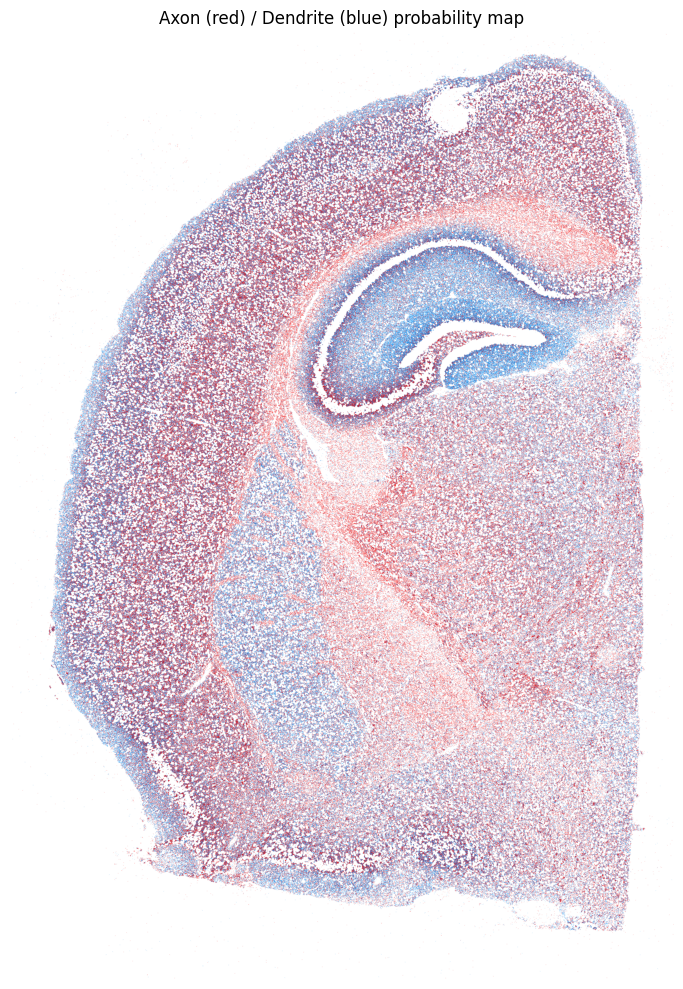

In [9]:
a_map = adata.uns['bin_probabilities'][:, 0].reshape(adata.uns['data_shape']).copy()
d_map = adata.uns['bin_probabilities'][:, 1].reshape(adata.uns['data_shape']).copy()

# zero out sub-threshold bins
a_map[a_map <= 0.5] = 0
d_map[d_map <= 0.5] = 0

cmap_red  = mcolors.LinearSegmentedColormap.from_list('axon',    ['#ffe6e6', '#ff1a1a', '#990000'])
cmap_blue = mcolors.LinearSegmentedColormap.from_list('dendrite',['#f0f8ff', '#1aa3ff', '#003399'])
norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

combined = np.ones(a_map.shape + (4,))          # white RGBA background
combined[a_map > 0] = cmap_red(norm(a_map))[a_map > 0]
combined[d_map > 0] = cmap_blue(norm(d_map))[d_map > 0]
combined_flipped = np.rot90(combined, 2)

fig, ax = plt.subplots(figsize=(7, 10))
ax.imshow(combined_flipped, aspect='equal')
ax.axis('off')
plt.title('Axon (red) / Dendrite (blue) probability map')
plt.tight_layout()
plt.show()

## 6. Compare axon and dendrite enrichment

`scoubi.tl.axon_dendrite_enrichment` runs a vectorized two-proportions z-test for every gene, comparing expression in axonic versus dendritic bins. It is a useful first pass for seeing whether the model is recovering recognizable compartment-specific signals.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `adata` | `AnnData` | - | Output from `overview` |
| `z_thr` | `float` | `3.0` | Z-score cutoff for the categorical labels |

This step stores the main comparison table in `uns['ptest_a_vs_d']` together with companion summaries of the fraction of each gene's expression assigned to axon and dendrite bins.


In [10]:
adata = scoubi.tl.axon_dendrite_enrichment(
    adata,
)

df_z = adata.uns['ptest_a_vs_d']
print(df_z.shape)
df_z.head()

(5027, 14)


,gene,c1,c2,n1,n2,zscore,pvalue,fdr,p1,p2,log2fc,mean_prop,label,is_marker
0,Kif5a,415715.0,54929.0,1128425,1037973,562.532074,0.0,0.0,0.368403,0.052919,2.799413,0.210661,axon,True
1,Slc17a7,201259.0,9950.0,1128425,1037973,418.348088,0.0,0.0,0.178354,0.009586,4.217671,0.093970,axon,True
2,Kif5c,175403.0,28187.0,1128425,1037973,323.263263,0.0,0.0,0.155441,0.027156,2.517030,0.091298,axon,True
3,Vamp2,196262.0,38778.0,1128425,1037973,322.878857,0.0,0.0,0.173926,0.037359,2.218929,0.105642,axon,True
4,Snap25,237163.0,93286.0,1128425,1037973,246.023180,0.0,0.0,0.210172,0.089873,1.225605,0.150022,axon,True


**Enrichment scatter.** `scoubi.pl.enrichment_scatter` gives a volcano-style summary with log2 fold-change on the x-axis and z-score on the y-axis.

| Parameter | Default | Description |
|---|---|---|
| `top_k` | `10` | Number of top upregulated and downregulated genes to label |
| `z_thr` | `3.0` | Z-score cutoff used for coloring |
| `lfc_clip` | `3.0` | Axis clip for log2 fold-change |
| `remove_markers` | `True` | Hide training markers in the plot |
| `figsize` | `(10, 8)` | Figure size |
| `label_fontsize` | `10` | Gene-label font size |


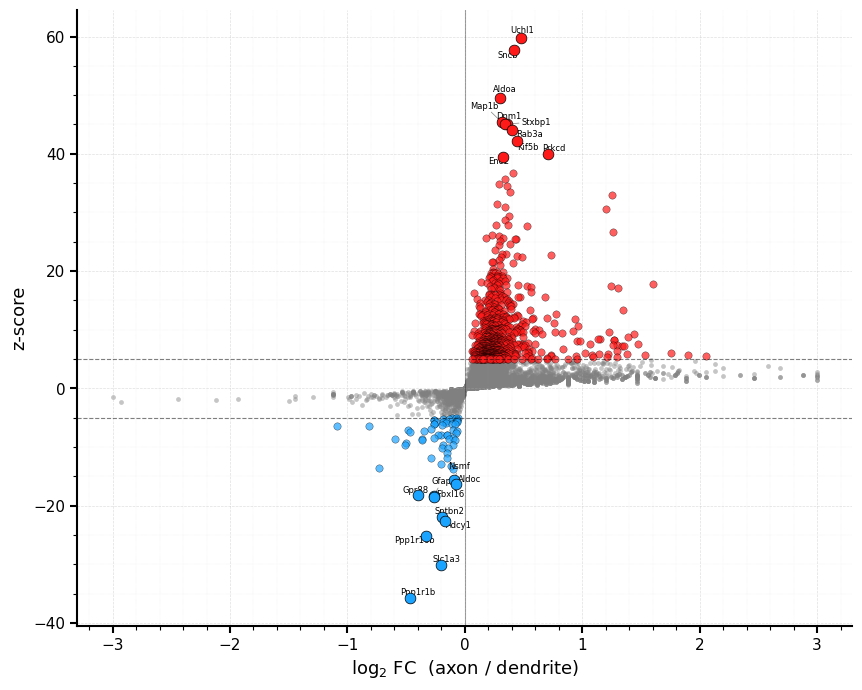

In [11]:
scoubi.pl.enrichment_scatter(
    adata,
    top_k          = 10,
    z_thr          = 5.0,
    lfc_clip       = 3.0,
    remove_markers = True,
    figsize        = (10, 8),
    show           = True,
)

**Manual volcano option.** If you want full control over styling, annotations, or downstream filtering, you can also build the enrichment scatter directly from `ptest_a_vs_d`.


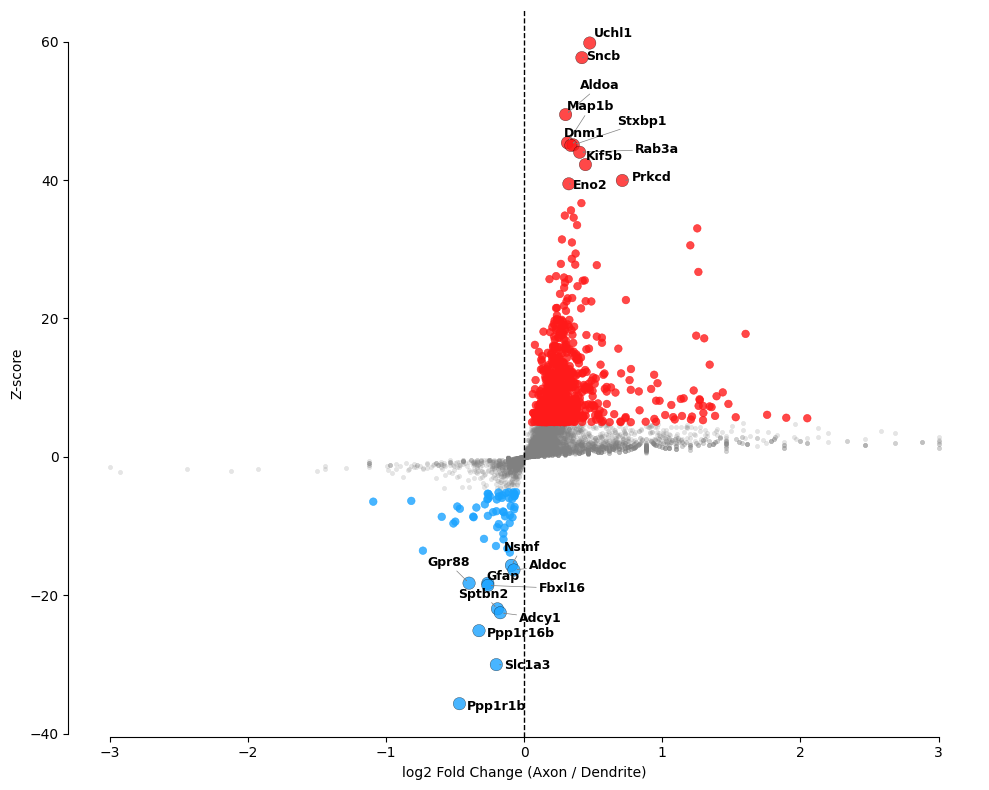

In [12]:
TOP_K, Z_THR = 10, 5

df = adata.uns['ptest_a_vs_d'].copy()
df = df[df.is_marker == False].copy()         # exclude training markers
df['log2fc_plot'] = df['log2fc'].clip(-3, 3)  # clip for display
df['significance'] = 'Not Significant'
df.loc[df['zscore'] >  Z_THR, 'significance'] = 'Upregulated'
df.loc[df['zscore'] < -Z_THR, 'significance'] = 'Downregulated'

highlight_idx = pd.concat([
    df.nlargest(TOP_K,  'zscore'),
    df.nsmallest(TOP_K, 'zscore')
]).index

palette = {'Upregulated': '#ff1a1a', 'Downregulated': '#1aa3ff'}

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(df[df.significance == 'Not Significant'],
                x='log2fc_plot', y='zscore', color='grey', s=10, alpha=0.2,
                edgecolor=None, ax=ax)
df_sig = df[df.significance != 'Not Significant']
sns.scatterplot(df_sig.drop(highlight_idx, errors='ignore'),
                x='log2fc_plot', y='zscore', hue='significance',
                palette=palette, s=30, alpha=0.8, edgecolor=None, legend=False, ax=ax)
sns.scatterplot(df_sig.loc[df_sig.index.intersection(highlight_idx)],
                x='log2fc_plot', y='zscore', hue='significance',
                palette=palette, s=80, alpha=0.8,
                edgecolor='black', linewidth=0.25, legend=False, ax=ax)

ax.axvline(0, color='k', linestyle='--', lw=1)
texts = [ax.text(r.log2fc_plot, r.zscore, r.gene, fontsize=9, weight='bold')
         for _, r in df_sig.loc[df_sig.index.intersection(highlight_idx)].iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

ax.set_xlabel('log2 Fold Change (Axon / Dendrite)')
ax.set_ylabel('Z-score')
sns.despine(trim=True)
plt.tight_layout()
plt.show()

## 7. Measure distance to the interface

`scoubi.tl.distance` links each interface bin to its nearest cells using a KD-tree on `obsm['bin']`. Those nearest-neighbor assignments are then reused by the profile steps that follow.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `adata` | `AnnData` | - | Output from `overview` |
| `k` | `int` | `1` | Number of nearest neighbors per interface bin |

The output is stored as `interface_knn_idx` and `interface_knn_dists` in `adata.uns`.


In [13]:
adata = scoubi.tl.distance(
    adata,
    k = 1,   # nearest-neighbour count; k=1 assigns each interface bin to the closest cell
)

print('KNN index shape:', adata.uns['interface_knn_idx'].shape)

KNN index shape: (66461, 1)


## 8. Build interface expression profiles

`scoubi.tl.expression_profile` summarizes gene expression around the interface after assigning each interface bin to its nearest cell. You can aggregate by cell type, region, or any other categorical field present in `adata.obs`.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `adata` | `AnnData` | - | Output from `distance` |
| `key` | `str` | `'cell_type'` | Observation column used for grouping |
| `normalize` | `bool` | `False` | Normalize by the global per-gene mean |
| `k` | `int` | `1` | Number of neighbors to use; should match the distance step |
| `threshold` | `float` | `0.05` | Minimum fraction of assigned interface bins required to keep a group |

The resulting profile table is saved to `uns[f'interface_{key}_profile']`, with an additional normalized table when `normalize=True`.


In [14]:
# Profile by brain region
adata = scoubi.tl.expression_profile(
    adata,
    key       = 'region',  # group interface bins by their nearest cell's region label
)

print(adata.uns['interface_region_profile'].shape)   # (n_regions, n_genes)
adata.uns['interface_region_profile'].head()

(4594, 7)


,CNU,CNU-HYa,CTX,Hippocampus,Hypothalamus,Thalamus,White Matter
A1cf,0.000000,0.000000,0.000043,0.000000,0.000000,0.000000,0.000000
A2m,0.000000,0.000000,0.000235,0.000370,0.000000,0.002316,0.000000
Aatf,0.002364,0.001838,0.001817,0.000647,0.000000,0.002573,0.002073
Abca1,0.002364,0.002574,0.002908,0.002679,0.008969,0.005919,0.003109
Abca13,0.000000,0.000000,0.000021,0.000000,0.000000,0.000000,0.000000


In [15]:
# Profile by cell type
adata = scoubi.tl.expression_profile(
    adata,
    key       = 'cell_type',
)

print(adata.uns['interface_cell_type_profile'].shape)

(4594, 16)


**Radviz view.** `scoubi.pl.radviz` is a compact way to see which genes are pulled toward particular regions or cell types in the interface profile.

| Parameter | Default | Description |
|---|---|---|
| `df_profile` | - | Profile matrix, usually transposed so genes are rows |
| `cell_types` | `None` | Ordered list of group names |
| `fraction_threshold` | `0.05` | Minimum dominant fraction for inclusion |
| `bandwidth` | `0.3` | KDE bandwidth |
| `beta` | `5` | Strength of attraction toward dominant groups |
| `radius_threshold` | `0.2` | Radius below which genes are treated as unresolved |
| `annotate` | `False` | Add gene labels |
| `annotation_radius` | `0.5` | Only annotate genes with larger radii |
| `s_scale` | `200` | Point-size scale |


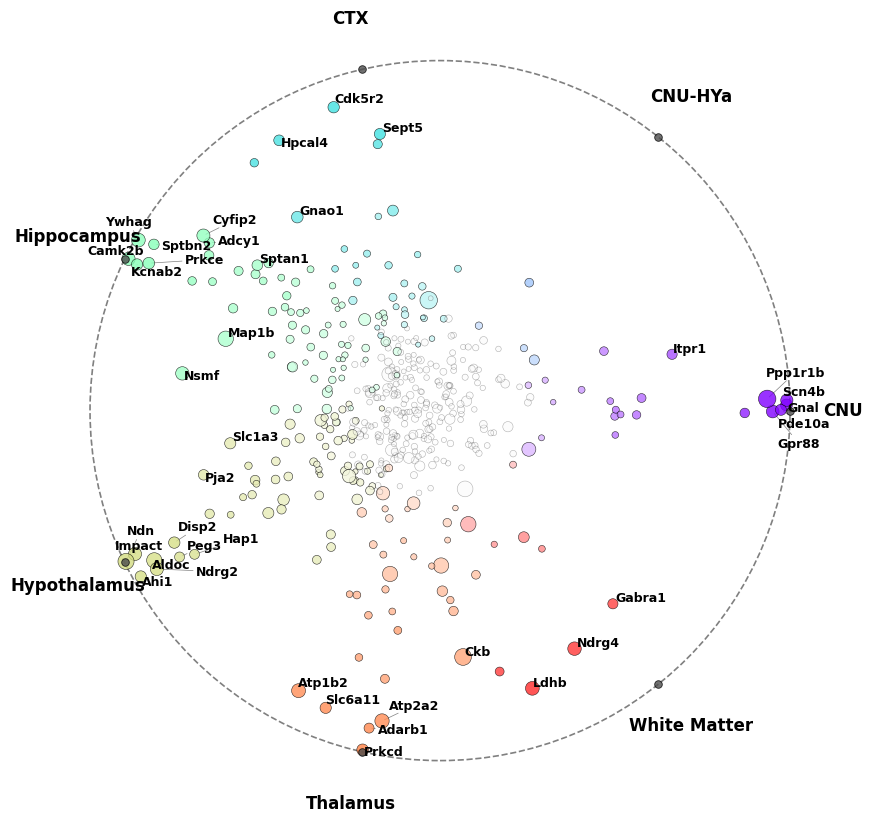

,Adarb1,Adcy1,Ahi1,Aldoc,Atp1b2,Atp2a2,Camk2b,Cdk5r2,Ckb,Cyfip2,...,Ppp1r1b,Prkcd,Prkce,Scn4b,Sept5,Slc1a3,Slc6a11,Sptan1,Sptbn2,Ywhag
CNU,0.013002,0.039007,0.021277,0.143026,0.082742,0.126478,0.176123,0.115839,0.286052,0.151300,...,0.315603,0.001182,0.096927,0.154846,0.085106,0.102837,0.016548,0.075650,0.044917,0.085106
CNU-HYa,0.013603,0.019118,0.076838,0.151103,0.110294,0.123162,0.094118,0.083456,0.181985,0.129044,...,0.011397,0.002574,0.069118,0.005147,0.093750,0.066544,0.049265,0.102206,0.028309,0.186397
CTX,0.016334,0.090307,0.009065,0.157823,0.092295,0.110104,0.092701,0.134605,0.188203,0.157310,...,0.025677,0.001219,0.079168,0.011523,0.128982,0.093535,0.023731,0.102920,0.075940,0.142344
Hippocampus,0.014135,0.108555,0.012380,0.112620,0.069383,0.104398,0.180340,0.096083,0.129250,0.177199,...,0.013396,0.004157,0.141168,0.006375,0.084904,0.067350,0.022450,0.119087,0.114745,0.197154
Hypothalamus,0.006726,0.006726,0.132287,0.242152,0.170404,0.121076,0.085202,0.067265,0.190583,0.156951,...,0.006726,0.002242,0.038117,0.008969,0.038117,0.130045,0.094170,0.073991,0.004484,0.127803
Thalamus,0.104220,0.083376,0.016727,0.215646,0.202265,0.212301,0.074627,0.072054,0.290273,0.119403,...,0.006691,0.139218,0.050952,0.039629,0.076686,0.072826,0.131498,0.100875,0.014925,0.142306
White Matter,0.027979,0.056995,0.010363,0.121244,0.076684,0.172021,0.062176,0.089119,0.267358,0.139896,...,0.010363,0.007254,0.094301,0.047668,0.095337,0.061140,0.035233,0.096373,0.034197,0.178238


In [16]:
coords = scoubi.pl.radviz(
    adata.uns['interface_region_profile'],
    return_genes       = True,
    fraction_threshold = 0.1,
    bandwidth          = 0.5,
    beta               = 15,
    annotate           = True,
    annotation_radius  = 0.6,
    annotation_size    = 0.1,
    s_scale            = 500,
)

# coords is a DataFrame with columns: assigned_group, radius, s
# Filter for well-resolved genes and inspect their expression
well_resolved = coords[
    (coords.assigned_group != 'None') &
    (coords.radius >= 0.1) &
    (coords.s >= 0.1)
]
adata.uns['interface_region_profile'].loc[well_resolved.index].T

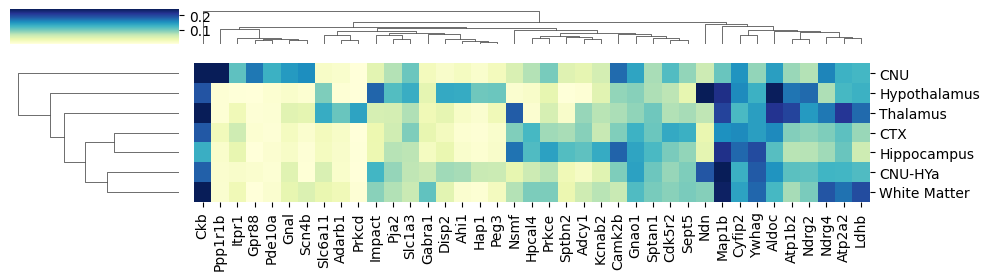

In [17]:
# Clustermap of the most region-specific interface genes
top_genes = well_resolved[well_resolved.radius >= 0.5].index
g = sns.clustermap(
    adata.uns['interface_region_profile'].loc[top_genes].T,
    robust  = True,
    cmap    = 'YlGnBu',
    figsize = (10, 3),
)
g.ax_heatmap.set_xticklabels(g.data2d.columns, rotation=90)
plt.tight_layout()
plt.show()

## 9. Build communication profiles

`scoubi.tl.communication_profile` maps significant CellWhisper ligand-receptor edges back to their nearest cells and counts those interactions by group. This is the communication-side companion to the interface expression profile above.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `adata` | `AnnData` | - | Output from `overview` and `distance` |
| `key` | `str` | `'cell_type'` | Observation column used for grouping |

The step stores the reconstructed edge dictionary in `uns['lr_edges']` and the grouped interaction matrix in `uns[f'communication_{key}_profile']`.


In [18]:
adata = scoubi.tl.communication_profile(
    adata,
    key = 'region',   # count L-R interactions per region
)

df = adata.uns['communication_region_profile'].copy()
print(df.shape)   # (n_regions, n_LR_pairs)
df.head()

(7, 67)


,Gad1_Gabrg1,Gja1_Gjb6,Slc17a6_Grik1,Slc32a1_Gabra5,Slc17a6_Gria1,Slc17a7_Grm3,Slc17a7_Gria1,Slc18a3_Ache,Slc17a6_Gria4,Slc17a6_Grin2d,...,Slc17a6_Grm2,Slc17a7_Grm2,Sst_Sstr1,Gjb6_Gja1,Slc17a7_Grm8,Slc17a6_Grik2,Slc32a1_Glra2,Slc32a1_Gabbr1,Gad2_Gabbr1,Slc17a7_Grin2c
CNU,2,46,0,5,0,13,130,9,0,0,...,0,2,0,25,4,0,1,194,149,7
CNU-HYa,21,69,6,18,293,23,362,11,32,21,...,11,25,6,70,4,20,35,396,261,9
CTX,19,836,8,27,151,2580,11542,0,32,5,...,27,1118,40,789,561,5,14,689,358,827
Hippocampus,1,81,1,20,69,305,6713,0,2,1,...,5,326,4,78,33,4,1,148,110,164
Hypothalamus,9,23,4,4,125,0,57,0,13,17,...,1,1,1,36,1,12,6,91,70,1


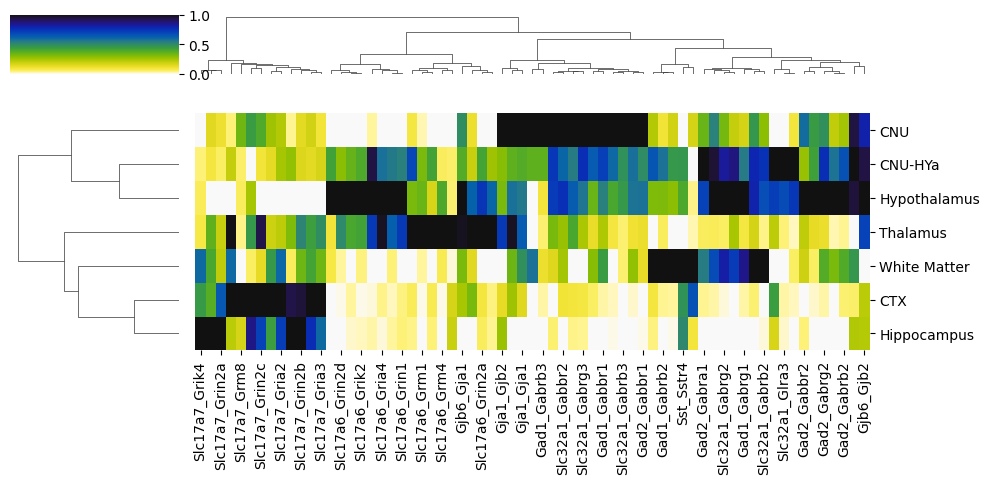

In [19]:
# Normalize by region cell count, then plot a heatmap
tree = cKDTree(adata.obsm['bin'])
all_edges = []
for edge_list in adata.uns['lr_edges'].values():
    for e in edge_list:
        all_edges.append((np.array(e[0]) + np.array(e[1])) / 2.0)
all_edges = np.array(all_edges)
_, idxs = tree.query(all_edges, k=1)
ct_counts = pd.Series(adata.obs['region'].values[idxs]).value_counts()

df_norm = df.div(ct_counts[df.index].values, axis=0)
df_norm = (df_norm - df_norm.min()) / (df_norm.max() - df_norm.min())

g = sns.clustermap(df_norm, cmap=cc.cm.CET_L16_r, robust=True,
                   figsize=(10, 5), method='ward')
plt.tight_layout()
plt.show()

## 10. Run the empirical background test

`scoubi.tl.empirical_background` compares interface expression to a matched background sampled from extrasomatic bins. This provides a useful check on whether genes enriched at the interface remain unusual after accounting for library-size structure.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `adata` | `AnnData` | - | Output from `overview` |
| `n_boot` | `int` | `10000` | Number of bootstrap samples |
| `n_strata` | `int` | `10` | Number of library-size strata used for matching |
| `interface_key` | `str` | `'interface_map'` | Interface map stored in `adata.uns` |
| `random_seed` | `int` | `42` | Random seed |

Results are written to `uns['empirical']` with interface means, matched-background means, empirical p-values, and z-scores.


In [20]:
adata = scoubi.tl.empirical_background(
    adata,
    n_boot      = 1000,            # bootstrap resamples
    n_strata    = 10,               # library-size strata for matched background
    interface_key = 'interface_map',
    random_seed = 42,
)

df_emp = adata.uns['empirical']
print(df_emp.shape)
df_emp.sort_values('zscore', ascending=False).head()

(5027, 7)


,gene,Interface Mean Expression,ESR Mean Expression,empirical_pvalue,zscore,is_marker,is_LR
4158,Slc17a7,0.388453,0.134508,0.000999,187.664016,True,True
1922,Gria2,0.110727,0.039928,0.000999,98.387120,True,True
535,Camk2a,0.427032,0.251062,0.000999,91.905013,True,False
1921,Gria1,0.070282,0.028720,0.000999,68.464345,True,True
2723,Map2,0.279863,0.185298,0.000999,57.508098,True,False


In [21]:
# Filter for non-marker, non-LR genes with strong interface enrichment
df_sig = (
    df_emp[
        (df_emp.is_marker == False) &
        (df_emp.is_LR     == False) &
        (df_emp.zscore > 3) &
        (df_emp.empirical_pvalue < 1e-3)
    ]
    .sort_values('zscore', ascending=False)
)
print(f'{len(df_sig)} interface-enriched genes')
df_sig.head(10)

384 interface-enriched genes


,gene,Interface Mean Expression,ESR Mean Expression,empirical_pvalue,zscore,is_marker,is_LR
3152,Nptxr,0.073592,0.046213,0.000999,33.757365,False,False
2119,Hpcal4,0.120868,0.082922,0.000999,33.494281,False,False
4374,Sptbn2,0.079987,0.054203,0.000999,29.844085,False,False
512,Cabp1,0.082650,0.059953,0.000999,23.884262,False,False
3706,Ptk2b,0.056499,0.039736,0.000999,23.210651,False,False
3611,Prkce,0.096312,0.074359,0.000999,22.224690,False,False
3582,Ppp3r1,0.075413,0.056765,0.000999,22.011611,False,False
536,Camk2b,0.119273,0.095867,0.000999,20.835262,False,False
4890,Vxn,0.041152,0.028349,0.000999,20.597025,False,False
1347,Egr3,0.036894,0.024576,0.000999,20.556878,False,False


## 11. Run GO enrichment

`scoubi.tl.get_panther` submits a gene list to the PANTHER API and returns Gene Ontology enrichment for biological process, cellular component, and molecular function terms. This is most useful after selecting a focused gene set from the enrichment or empirical tests.

| Parameter | Type | Description |
|---|---|---|
| `gene_list` | `str` | Comma-separated gene symbols to test |
| `background` | `str` | Comma-separated background gene set |
| `organism` | `str` | NCBI taxon ID; default is `'10090'` for mouse |


In [22]:
# Use interface-enriched genes as the test set; all measured genes as background
test_genes  = ','.join(df_sig['gene'].values)
background  = ','.join(adata.uns['genes'])

df_go = scoubi.tl.get_panther(test_genes, background)
df_go.head(10)

,number_in_list,fold_enrichment,fdr,expected,number_in_reference,pValue,term,id,dataset
0,189,2.497747,3.982741e-39,75.668185,975,5.585891e-42,synapse,GO:0045202,CC
1,120,3.098646,4.260489e-31,38.726589,499,1.195088e-33,glutamatergic synapse,GO:0098978,CC
2,199,2.061218,5.593056e-29,96.544843,1244,2.353320e-31,cell junction,GO:0030054,CC
3,122,2.822253,1.009501e-27,43.227876,557,5.663397e-30,postsynapse,GO:0098794,CC
4,101,2.798722,6.705647e-22,36.087903,465,4.702417e-24,presynapse,GO:0098793,CC
5,130,2.045270,6.194782e-16,63.561275,819,5.213000e-18,neuron projection,GO:0043005,CC
6,66,3.092449,6.438253e-16,21.342308,275,6.320865e-18,neuron to neuron synapse,GO:0098984,CC
7,62,3.170169,1.771261e-15,19.557315,252,1.987390e-17,asymmetric synapse,GO:0032279,CC
8,64,3.077064,2.257790e-15,20.799050,268,2.849945e-17,postsynaptic specialization,GO:0099572,CC
9,59,3.235009,3.362936e-15,18.237973,235,4.716601e-17,postsynaptic density,GO:0014069,CC


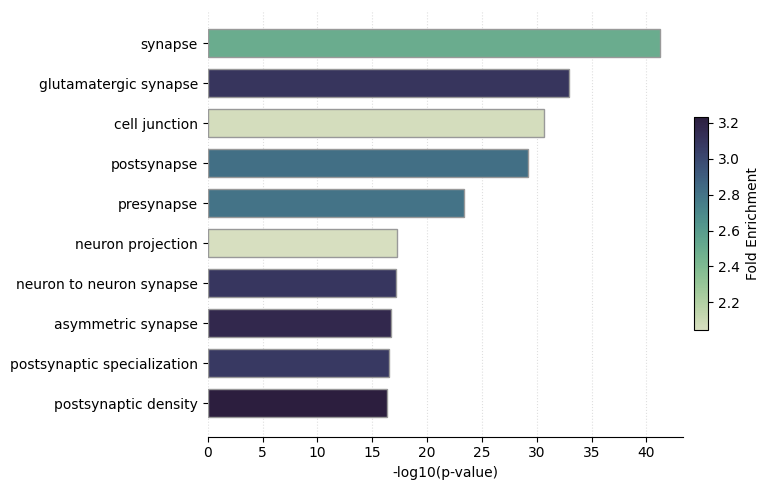

In [23]:
# Horizontal bar chart of top GO terms
df_plot = df_go.head(10).copy().sort_values('pValue', ascending=False)
vals = -np.log10(df_plot['pValue'])
fe   = df_plot['fold_enrichment']

norm = mcolors.Normalize(vmin=fe.min(), vmax=fe.max())
cmap = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_plot['term'], vals, color=cmap(norm(fe)),
        edgecolor='#999999', linewidth=1, height=0.7)
ax.set_xlabel('-log10(p-value)')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, aspect=15, pad=0.02)
cbar.set_label('Fold Enrichment')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.grid(True, linestyle=':', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 12. Test regional enrichment patterns

`scoubi.tl.p_test` asks a region-aware question: for each gene and region, is interface expression proportionally higher than expression in cell bins or the extrasomatic background? SCOUBI reports the results for all cells together and then separately for neuronal and non-neuronal subsets.

| Parameter | Type | Default | Description |
|---|---|---|---|
| `adata` | `AnnData` | - | Output from `overview` and `distance` |
| `cell_type_key` | `str` | `'cell_type'` | Observation column containing cell types |
| `region_key` | `str` | `'region'` | Observation column containing regions |
| `interface_key` | `str` | `'interface_map'` | Interface map used for the test |
| `neuron_patterns` | `list[str]` | built in | Substrings used to identify neuronal cell types |
| `min_interface_prop` | `float` | `0.01` | Minimum regional interface fraction required for testing |
| `exclude_regions` | `list[str]` | `[]` | Regions to skip |
| `z_sig_thr` | `float` | `3.0` | Z-score threshold used for region significance counts |

The main outputs are the long-format regional test table plus best-rank summaries for all cells, neuronal cells, and non-neuronal cells.


In [24]:
adata = scoubi.tl.p_test(
    adata,
    cell_type_key      = 'cell_type',
    region_key         = 'region',
    min_interface_prop = 0.01,
    exclude_regions    = ["White Matter"],
    z_sig_thr          = 3.0,
)

print(adata.uns['regional_ptest'].shape)
adata.uns['regional_ptest'].head()

(35189, 22)


,region,gene,z_interface,z_cell,z_cell_neuronal,z_cell_non_neuronal,z_esb,interface_prop_region,interface_prop_other,cell_prop_region,...,cell_prop_other,cell_prop_other_neuronal,cell_prop_other_non_neuronal,esb_prop_region,esb_prop_other,p_interface,p_cell,p_cell_neuronal,p_cell_non_neuronal,p_esb
0,CNU,A1cf,-0.160585,-1.834099,-1.686479,-1.065180,0.142621,0.000000,0.000030,0.000207,...,0.001080,0.001476,0.000685,0.000010,0.000009,0.872420,6.663934e-02,0.091704,2.867946e-01,8.865895e-01
1,CNU,A2m,-0.556375,-10.605597,-3.082736,-8.280491,-8.283527,0.000000,0.000366,0.005377,...,0.032729,0.008169,0.057242,0.000164,0.000507,0.577954,0.000000e+00,0.002051,2.220446e-16,2.220446e-16
2,CNU,Aatf,0.497459,4.296971,0.100651,1.985746,-0.959941,0.002364,0.001661,0.186763,...,0.162909,0.219976,0.105954,0.000592,0.000637,0.618865,1.731481e-05,0.919828,4.706149e-02,3.370850e-01
3,CNU,Abca1,-0.373285,-7.763132,-4.102414,0.229794,-6.121214,0.002364,0.003079,0.134230,...,0.178374,0.078188,0.278364,0.001611,0.002138,0.708936,8.215650e-15,0.000041,8.182521e-01,9.286480e-10
4,CNU,Abca13,-0.113550,-0.356540,0.315563,-1.237768,-2.106816,0.000000,0.000015,0.000827,...,0.000994,0.001064,0.000925,0.000023,0.000051,0.909595,7.214363e-01,0.752334,2.158023e-01,3.513350e-02


**Regional enrichment scatter.** `scoubi.pl.regional_enrichment` compares best region ranks for cell bins versus interface bins and colors each gene by its strongest region.

| Parameter | Default | Description |
|---|---|---|
| `best_rank_key` | `'ptest_best_rank'` | Best-rank table to plot |
| `region_color_map` | `None` | Optional custom region colors |
| `z_interface_thr` | `3.0` | Interface z-score threshold |
| `z_esb_thr` | `2.0` | Extrasomatic background threshold |
| `label_ratio_thr` | `2.0` | Label genes whose cell/interface rank ratio exceeds this value |


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


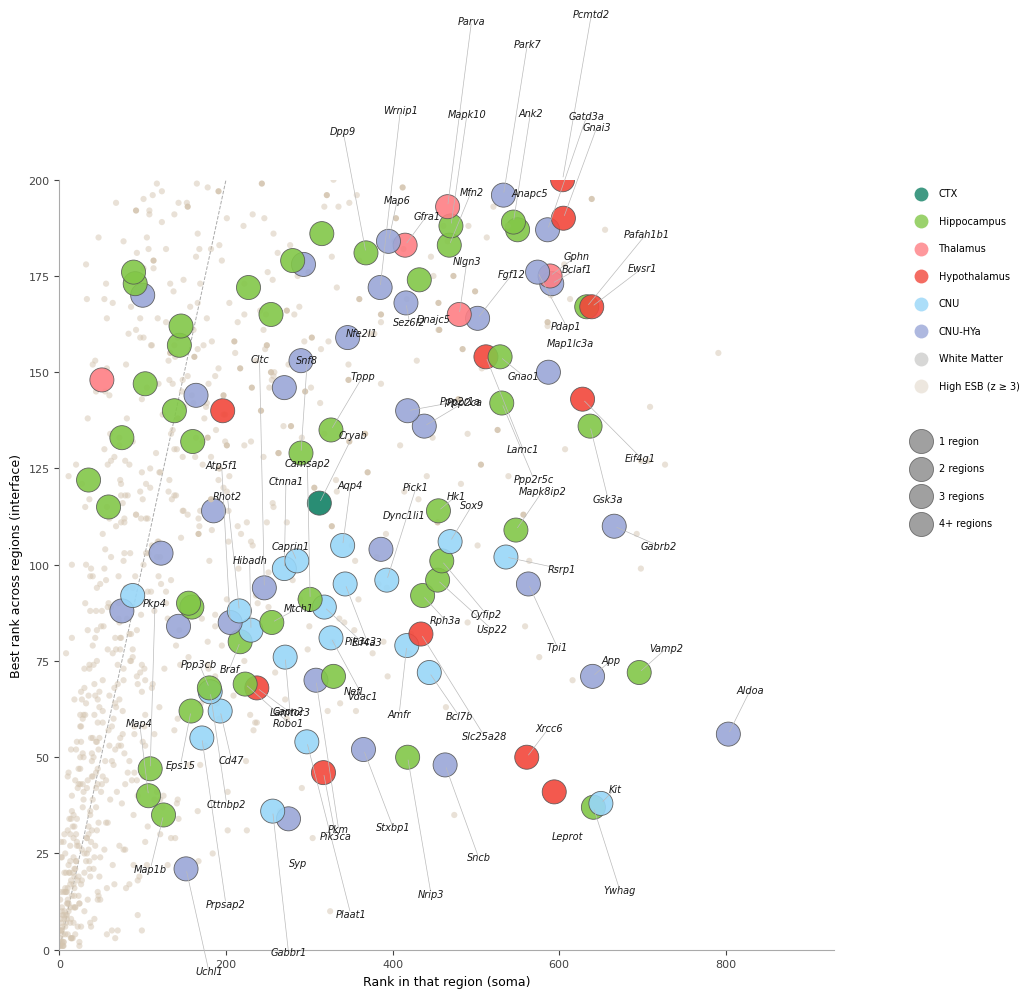

In [25]:
scoubi.pl.regional_enrichment(
    adata,
    best_rank_key   = 'ptest_best_rank_neuronal', show = True
)

## 13. Inspect the annotated AnnData object

At this point the `AnnData` object contains both the original data representation and a layered set of SCOUBI results. The `adata.summarize()` helper provides a quick grouped overview of the keys created across the pipeline.

**`adata.summarize()`** prints stored outputs by stage so you can confirm what has been added before saving or passing the object downstream.


In [26]:
adata.summarize()

AnnData object with n_obs × n_vars = 63162 × 5027
obs: cell_type, region
obsm: spatial, bin
uns:
  data                  : transcripts_path, data_shape, binned_data_shape, mask_cell, mask_ecm, binned_data, axon_markers, dendrite_markers, genes, lr_pairs
  annotations           : bin_probabilities, bin_scores
  maps                  : axon_map, dendrite_map, interface_map
  enrichment            : axon_enrichment_df, dendrite_enrichment_df
  comparison            : ptest_a_vs_d
  testing               : empirical, regional_ptest, ptest_best_rank, ptest_best_rank_neuronal, ptest_best_rank_non_neuronal
  interface             : interface_cell_type_profile, interface_region_profile
  communication         : cellwhisper, cellwhisper_unfiltered, cellwhisper_lr, communication_region_profile, lr_edges
  misc                  : interface_knn_idx, interface_knn_dists, model_weights


A typical full run will populate groups such as:

| Group | Example keys |
|---|---|
| `data` | `transcripts_path`, `binned_data_shape`, `mask_cell`, `mask_ecm`, `genes`, `lr_pairs` |
| `annotations` | `bin_probabilities`, `bin_scores` |
| `maps` | `axon_map`, `dendrite_map`, `interface_map` |
| `enrichment` | `axon_enrichment_df`, `dendrite_enrichment_df`, `ptest_a_vs_d` |
| `testing` | `empirical`, `regional_ptest`, `ptest_best_rank` and related summaries |
| `interface` | `interface_region_profile`, `interface_cell_type_profile` |
| `communication` | `cellwhisper`, `cellwhisper_lr`, `communication_region_profile`, `lr_edges` |
| `misc` | `interface_knn_idx`, `interface_knn_dists`, `model_weights` |


## 14. Save and reload results

Once the analysis looks good, save the processed object to `.h5ad` so you can reopen it without rerunning every step. Reloading through `load_data` re-attaches the `summarize()` and `get_transcripts()` helpers.


In [27]:
# Save
adata.write_h5ad('data.h5ad')
print('Saved.')

Saved.


In [28]:
# Reload — convenience methods are automatically re-attached
adata = scoubi.io.load_data('data.h5ad')
adata.summarize()

AnnData object with n_obs × n_vars = 63162 × 5027
obs: cell_type, region
obsm: bin, spatial
uns:
  data                  : transcripts_path, data_shape, binned_data_shape, mask_cell, mask_ecm, binned_data, axon_markers, dendrite_markers, genes, lr_pairs
  annotations           : bin_probabilities, bin_scores
  maps                  : axon_map, dendrite_map, interface_map
  enrichment            : axon_enrichment_df, dendrite_enrichment_df
  comparison            : ptest_a_vs_d
  testing               : empirical, regional_ptest, ptest_best_rank, ptest_best_rank_neuronal, ptest_best_rank_non_neuronal
  interface             : interface_cell_type_profile, interface_region_profile
  communication         : cellwhisper, cellwhisper_unfiltered, cellwhisper_lr, communication_region_profile, lr_edges
  misc                  : interface_knn_idx, interface_knn_dists, model_weights


## 15. Runtime statistics


In [29]:
# ── Total notebook runtime & final resource snapshot ─────────────────────────
_nb_elapsed  = time.perf_counter() - _nb_start
_nb_ram_end  = _nb_proc.memory_info().rss / 1024**3
_vm          = psutil.virtual_memory()
_cpu_pct     = psutil.cpu_percent(interval=1)   # 1-second sample

mins, secs = divmod(_nb_elapsed, 60)
hrs,  mins = divmod(mins, 60)

print(f"\n{'='*55}")
print(f"  NOTEBOOK RUNTIME")
print(f"    Total elapsed    : {int(hrs):02d}h {int(mins):02d}m {secs:05.2f}s")
print(f"    Training portion : {_train_elapsed/60:.1f} min  ({_train_elapsed/_nb_elapsed*100:.1f}% of total)")
print(f"\n  MEMORY")
print(f"    RAM baseline     : {_nb_ram_base:.2f} GB")
print(f"    RAM final        : {_nb_ram_end:.2f} GB  (Δ {_nb_ram_end - _nb_ram_base:+.2f} GB)")
print(f"    System RAM used  : {_vm.used / 1024**3:.1f} / {_vm.total / 1024**3:.1f} GB  ({_vm.percent:.1f}%)")
print(f"\n  CPU")
print(f"    CPU utilisation  : {_cpu_pct:.1f}%  (logical cores: {psutil.cpu_count()})")
if torch.cuda.is_available():
    print(f"\n  GPU")
    for i in range(torch.cuda.device_count()):
        props   = torch.cuda.get_device_properties(i)
        cur_gb  = torch.cuda.memory_allocated(i)  / 1024**3
        peak_gb = torch.cuda.max_memory_allocated(i) / 1024**3
        tot_gb  = props.total_memory / 1024**3
        print(f"    GPU {i} ({props.name})")
        print(f"      Current alloc : {cur_gb:.2f} GB")
        print(f"      Peak alloc    : {peak_gb:.2f} GB")
        print(f"      Total VRAM    : {tot_gb:.1f} GB")
print(f"{'='*55}\n")


  NOTEBOOK RUNTIME
    Total elapsed    : 01h 11m 06.79s
    Training portion : 11.3 min  (15.9% of total)

  MEMORY
    RAM baseline     : 0.78 GB
    RAM final        : 53.26 GB  (Δ +52.48 GB)
    System RAM used  : 375.9 / 2014.9 GB  (18.6%)

  CPU
    CPU utilisation  : 40.9%  (logical cores: 64)

  GPU
    GPU 0 (NVIDIA H200)
      Current alloc : 0.06 GB
      Peak alloc    : 49.06 GB
      Total VRAM    : 139.8 GB

